In [8]:
import mysql.connector

# Connect to MySQL database
cnx = mysql.connector.connect(user='root', 
                              password='java123@sql', 
                              host='localhost', 
                              port=3306, 
                              database='mysql')

# Create a cursor object to execute queries
cursor = cnx.cursor()

# Execute the SQL query to show databases
cursor.execute("SHOW DATABASES;")

# Fetch all the databases
databases = cursor.fetchall()

# Print the list of databases
for db in databases:
   print(db)

# Close the cursor and connection
cursor.close()
cnx.close()

('employees',)
('information_schema',)
('mysql',)
('performance_schema',)
('sys',)
('test_iti',)


/tmp/ipykernel_178202/2767829615.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


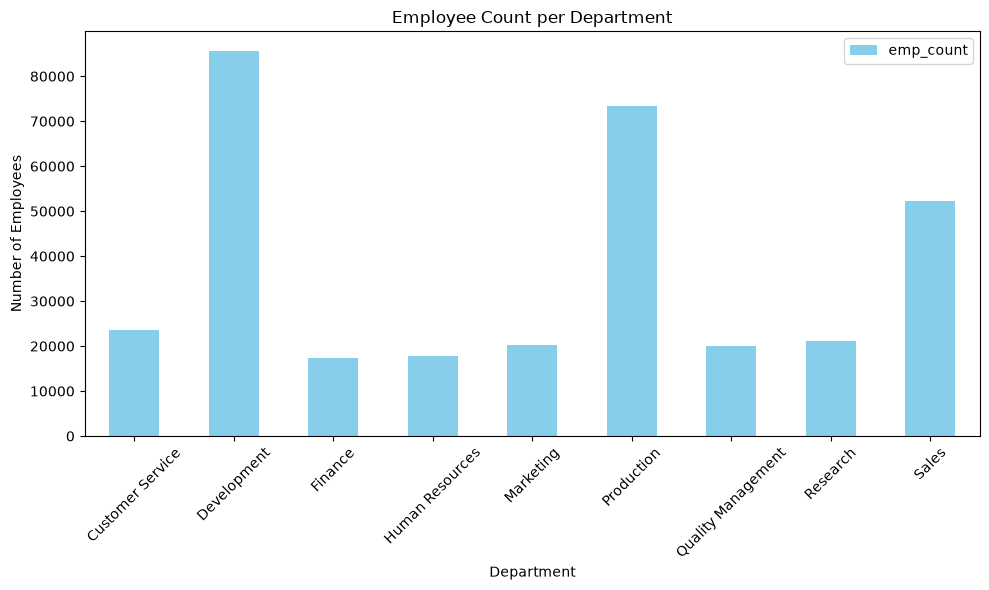

In [11]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to MySQL database using your pattern
try:
    cnx = mysql.connector.connect(
        user='root', 
        password='java123@sql', 
        host='localhost', 
        port=3306, 
        database='employees'
    )

    # 2. Load data into a DataFrame
    # Using your connection object directly with pandas
    query = """
    SELECT dept_name, COUNT(emp_no) as emp_count
    FROM dept_emp de
    JOIN departments d ON de.dept_no = d.dept_no
    GROUP BY dept_name
    """
    
    df = pd.read_sql(query, cnx)

    # 3. Visualize the data
    df.plot(kind='bar', x='dept_name', y='emp_count', figsize=(10, 6), color='skyblue')

    plt.title("Employee Count per Department")
    plt.xlabel("Department")
    plt.ylabel("Number of Employees")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

except mysql.connector.Error as err:
    print(f"Error: {err}")

finally:
    # 4. Close the connection
    if 'cnx' in locals() and cnx.is_connected():
        cnx.close()

/tmp/ipykernel_178202/2629122222.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


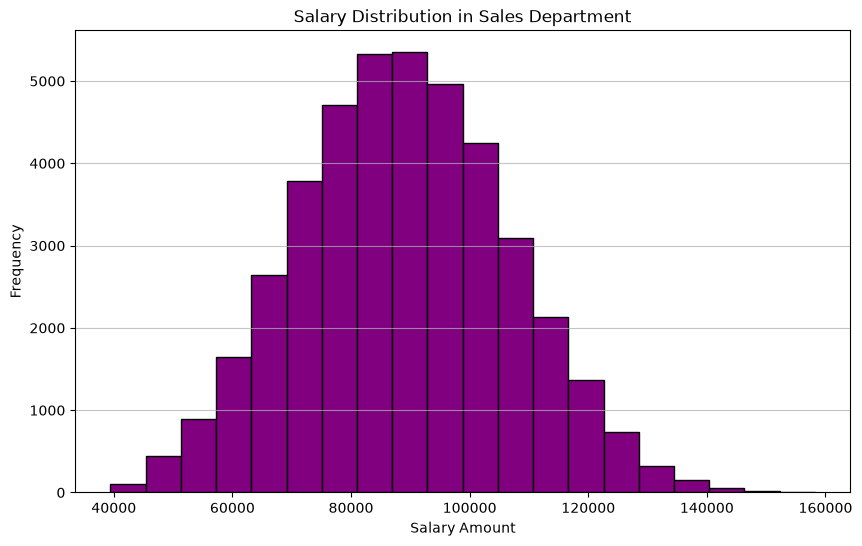

In [12]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt

try:
    # 1. Connect to MySQL database using your pattern
    cnx = mysql.connector.connect(
        user='root', 
        password='java123@sql', 
        host='localhost', 
        port=3306, 
        database='employees'
    )

    # 2. Load salary data for a specific department (e.g., 'Sales')
    # Using a JOIN to filter by department name
    query = """
    SELECT s.salary
    FROM salaries s
    JOIN dept_emp de ON s.emp_no = de.emp_no
    JOIN departments d ON de.dept_no = d.dept_no
    WHERE d.dept_name = 'Sales' AND s.to_date = '9999-01-01'
    """
    
    df = pd.read_sql(query, cnx)

    # 3. Use Matplotlib to plot a histogram
    plt.figure(figsize=(10, 6))
    plt.hist(df['salary'], bins=20, color='purple', edgecolor='black')

    # 4. Add labels and title
    plt.title("Salary Distribution in Sales Department")
    plt.xlabel("Salary Amount")
    plt.ylabel("Frequency")
    plt.grid(axis='y', alpha=0.75)
    plt.show()

except mysql.connector.Error as err:
    print(f"Error: {err}")

finally:
    # 5. Close the connection
    if 'cnx' in locals() and cnx.is_connected():
        cnx.close()